# Project Part 3 — Channel Coding
## Text Source: Character-Level

In [1]:
import math, random, collections
import matplotlib.pyplot as plt

# --- Reuse compressed bitstream from Part 2 ---
# We re-build Huffman code and compress the text
import heapq

with open('Text.txt','r',encoding='utf-8') as f:
    raw = f.read()
symbols = list(raw.lower())
n = len(symbols)
probs = {x:c/n for x,c in collections.Counter(symbols).items()}

def build_huffman(prob_dict):
    heap=[[p,i,sym,None,None] for i,(sym,p) in enumerate(prob_dict.items())]
    heapq.heapify(heap);nid=len(prob_dict)
    while len(heap)>1:
        l=heapq.heappop(heap);r=heapq.heappop(heap)
        heapq.heappush(heap,[l[0]+r[0],nid,None,l,r]);nid+=1
    return heap[0]

def get_codes(tree,prefix='',codes={}):
    if tree[2] is not None:codes[tree[2]]=prefix or '0'
    else:get_codes(tree[3],prefix+'0',codes);get_codes(tree[4],prefix+'1',codes)
    return codes

tree  = build_huffman(probs)
codes = get_codes(tree,'',{})
rev   = {v:k for k,v in codes.items()}

# Compress a sample of text
sample_symbols = symbols[:5000]
compressed_bits = [int(b) for s in sample_symbols for b in codes[s]]
print(f'Original symbols  : {len(sample_symbols)}')
print(f'Compressed bits   : {len(compressed_bits)}')
print(f'Bits/symbol       : {len(compressed_bits)/len(sample_symbols):.4f}')

Original symbols  : 5000
Compressed bits   : 21591
Bits/symbol       : 4.3182


---
## Task 1 — Binary Symmetric Channel (BSC)
### Q1a: Implement the BSC — each bit is flipped with probability p

In [2]:
def bsc(bits, p, seed=42):
    # Flip each bit independently with probability p
    rng = random.Random(seed)
    return [b ^ (1 if rng.random() < p else 0) for b in bits]

# Test: p=0 should give zero errors
noisy = bsc(compressed_bits, p=0.0)
print(f'p=0.0: errors = {sum(a!=b for a,b in zip(compressed_bits, noisy))}')

# Test: p=0.5 should give ~50% errors
noisy = bsc(compressed_bits, p=0.5)
print(f'p=0.5: errors = {sum(a!=b for a,b in zip(compressed_bits, noisy))}/{len(compressed_bits)}')

p=0.0: errors = 0
p=0.5: errors = 10746/21591


### Q1b: Measure bit error rate and evaluate effect on decoded text

In [3]:
def bits_to_symbols(bits, rev_codes):
    decoded, buf = [], ''
    for bit in bits:
        buf += str(bit)
        if buf in rev_codes:
            decoded.append(rev_codes[buf]); buf=''
        if len(buf) > 30:  # safety: reset if no match found
            buf=''
    return decoded

for p in [1e-3, 1e-2, 5e-2]:
    noisy = bsc(compressed_bits, p)
    ber   = sum(a!=b for a,b in zip(compressed_bits, noisy)) / len(compressed_bits)
    decoded = bits_to_symbols(noisy, rev)
    # Symbol error rate
    min_len = min(len(decoded), len(sample_symbols))
    ser = sum(a!=b for a,b in zip(decoded[:min_len], sample_symbols[:min_len])) / min_len if min_len>0 else 1.0
    print(f'p={p:.0e}: BER={ber:.4f}, SER={ser:.4f}, decoded {len(decoded)} symbols')

p=1e-03: BER=0.0014, SER=0.8329, decoded 4998 symbols
p=1e-02: BER=0.0104, SER=0.9412, decoded 4970 symbols
p=5e-02: BER=0.0484, SER=0.9252, decoded 4922 symbols


### Q1c: Sensitivity of compressed data to errors

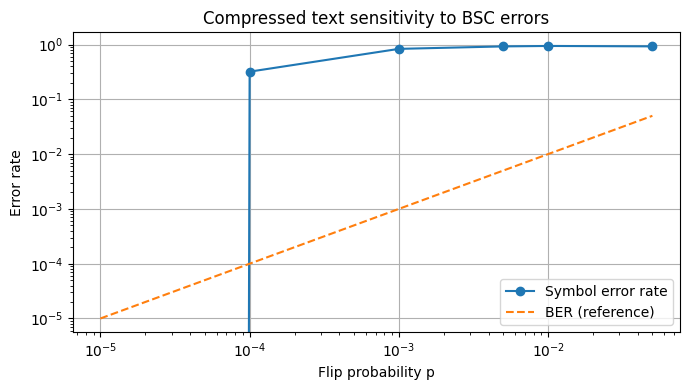

Compressed data is very sensitive — one bit error can corrupt many symbols!


In [4]:
p_vals = [0, 1e-4, 1e-3, 5e-3, 1e-2, 5e-2]
bers, sers = [], []
for p in p_vals:
    noisy = bsc(compressed_bits, p)
    ber = sum(a!=b for a,b in zip(compressed_bits,noisy))/len(compressed_bits)
    decoded = bits_to_symbols(noisy, rev)
    min_len = min(len(decoded), len(sample_symbols))
    ser = sum(a!=b for a,b in zip(decoded[:min_len],sample_symbols[:min_len]))/max(min_len,1)
    bers.append(ber); sers.append(ser)

fig, ax = plt.subplots(figsize=(7,4))
ax.loglog([p if p>0 else 1e-5 for p in p_vals], sers, marker='o', label='Symbol error rate')
ax.loglog([p if p>0 else 1e-5 for p in p_vals], [p if p>0 else 1e-5 for p in p_vals],
           linestyle='--', label='BER (reference)')
ax.set_xlabel('Flip probability p'); ax.set_ylabel('Error rate')
ax.set_title('Compressed text sensitivity to BSC errors')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig('text_bsc_sensitivity.png',dpi=100); plt.show()
print('Compressed data is very sensitive — one bit error can corrupt many symbols!')

---
## Task 2 — Repetition Coding
### Q2a: Implement repetition coding with factors r=3,5,7

In [ ]:
def repeat_encode(bits, r):
    # Repeat each bit r times
    return [b for b in bits for _ in range(r)]

def repeat_decode(bits, r):
    # Majority vote on each group of r bits
    decoded = []
    for i in range(0, len(bits)-r+1, r):
        group = bits[i:i+r]
        decoded.append(1 if sum(group) > r//2 else 0)
    return decoded

p = 0.01  # flip probability
print(f'Repetition coding at p={p}:')
for r in [3, 5, 7]:
    encoded = repeat_encode(compressed_bits, r)
    noisy   = bsc(encoded, p)
    decoded = repeat_decode(noisy, r)
    # Bit error rate after decoding
    min_len = min(len(decoded), len(compressed_bits))
    ber_out = sum(a!=b for a,b in zip(decoded[:min_len],compressed_bits[:min_len]))/min_len
    rate = 1/r  # effective information rate
    print(f'  r={r}: BER after decoding={ber_out:.6f}, effective rate={rate:.3f} bits/channel_bit')

### Q2b: Symbol error rate after repetition coding

In [ ]:
p = 0.01
print(f'Symbol error rate after repetition coding (p={p}):')
print(f'  No coding: ', end='')
noisy = bsc(compressed_bits, p)
dec = bits_to_symbols(noisy, rev)
ml = min(len(dec),len(sample_symbols))
print(f'{sum(a!=b for a,b in zip(dec[:ml],sample_symbols[:ml]))/max(ml,1):.4f}')

for r in [3, 5, 7]:
    enc   = repeat_encode(compressed_bits, r)
    noisy = bsc(enc, p)
    bits_dec = repeat_decode(noisy, r)
    dec = bits_to_symbols(bits_dec, rev)
    ml = min(len(dec),len(sample_symbols))
    ser = sum(a!=b for a,b in zip(dec[:ml],sample_symbols[:ml]))/max(ml,1)
    print(f'  r={r}: SER={ser:.4f}')

---
## Task 3 — Hamming(7,4) Coding
### Q3a: Implement Hamming(7,4) encoder and decoder

In [ ]:
# Hamming(7,4): encode 4 data bits into 7 bits with 3 parity bits
# Parity bit positions: 1,2,4 (1-indexed)
# Data bit positions  : 3,5,6,7 (1-indexed)

def hamming_encode_nibble(d):
    # d: list of 4 bits [d1,d2,d3,d4]
    d1,d2,d3,d4 = d
    p1 = d1 ^ d2 ^ d4
    p2 = d1 ^ d3 ^ d4
    p3 = d2 ^ d3 ^ d4
    return [p1, p2, d1, p3, d2, d3, d4]

def hamming_decode_nibble(c):
    # c: list of 7 bits, returns 4 corrected data bits
    p1,p2,d1,p3,d2,d3,d4 = c
    s1 = p1 ^ d1 ^ d2 ^ d4
    s2 = p2 ^ d1 ^ d3 ^ d4
    s3 = p3 ^ d2 ^ d3 ^ d4
    syndrome = s1 + 2*s2 + 4*s3  # error position (1-indexed)
    bits = list(c)
    if syndrome != 0:
        bits[syndrome-1] ^= 1  # flip erroneous bit
    return [bits[2], bits[4], bits[5], bits[6]]  # data bits

def hamming_encode(bits):
    # Pad to multiple of 4
    padded = bits + [0]*((4 - len(bits)%4)%4)
    encoded = []
    for i in range(0,len(padded),4):
        encoded.extend(hamming_encode_nibble(padded[i:i+4]))
    return encoded

def hamming_decode(bits):
    decoded = []
    for i in range(0,len(bits)-6,7):
        decoded.extend(hamming_decode_nibble(bits[i:i+7]))
    return decoded

# Quick test
test_bits = [1,0,1,1,0,0,1,0]
enc = hamming_encode(test_bits)
# Introduce one error
enc[2] ^= 1
dec = hamming_decode(enc)
print(f'Original : {test_bits}')
print(f'Decoded  : {dec[:len(test_bits)]}')
print(f'Correct? : {dec[:len(test_bits)]==test_bits}')

### Q3b: Transmit compressed text through BSC with Hamming protection

In [ ]:
print('Hamming(7,4) coding:')
for p in [1e-3, 1e-2, 5e-2]:
    enc   = hamming_encode(compressed_bits)
    noisy = bsc(enc, p)
    dec_bits = hamming_decode(noisy)
    # BER after Hamming decoding
    ml = min(len(dec_bits), len(compressed_bits))
    ber = sum(a!=b for a,b in zip(dec_bits[:ml],compressed_bits[:ml]))/max(ml,1)
    # Effective rate = 4/7
    dec_syms = bits_to_symbols(dec_bits, rev)
    ml2 = min(len(dec_syms),len(sample_symbols))
    ser = sum(a!=b for a,b in zip(dec_syms[:ml2],sample_symbols[:ml2]))/max(ml2,1)
    print(f'  p={p:.0e}: BER={ber:.6f}, SER={ser:.4f}, rate=4/7={4/7:.3f}')

---
## Task 4 — Comparison of All Schemes
### Q4a: Full comparison table

In [ ]:
p = 0.01
print(f'=== Channel Coding Comparison (text, p={p}) ===')
print(f'{"Scheme":<25} {"Rate":>8} {"BER out":>12} {"SER":>10}')
print('-'*60)

# No coding
noisy = bsc(compressed_bits, p)
ber = sum(a!=b for a,b in zip(compressed_bits,noisy))/len(compressed_bits)
dec = bits_to_symbols(noisy,rev)
ml = min(len(dec),len(sample_symbols))
ser = sum(a!=b for a,b in zip(dec[:ml],sample_symbols[:ml]))/max(ml,1)
print(f'{"No coding":<25} {"1.000":>8} {ber:>12.6f} {ser:>10.4f}')

# Repetition
for r in [3, 5, 7]:
    enc = repeat_encode(compressed_bits,r)
    noisy = bsc(enc,p)
    db = repeat_decode(noisy,r)
    ml2 = min(len(db),len(compressed_bits))
    ber = sum(a!=b for a,b in zip(db[:ml2],compressed_bits[:ml2]))/max(ml2,1)
    dec = bits_to_symbols(db,rev)
    ml3 = min(len(dec),len(sample_symbols))
    ser = sum(a!=b for a,b in zip(dec[:ml3],sample_symbols[:ml3]))/max(ml3,1)
    print(f'{f"Repetition r={r}":<25} {1/r:>8.3f} {ber:>12.6f} {ser:>10.4f}')

# Hamming
enc = hamming_encode(compressed_bits)
noisy = bsc(enc,p)
db = hamming_decode(noisy)
ml2 = min(len(db),len(compressed_bits))
ber = sum(a!=b for a,b in zip(db[:ml2],compressed_bits[:ml2]))/max(ml2,1)
dec = bits_to_symbols(db,rev)
ml3 = min(len(dec),len(sample_symbols))
ser = sum(a!=b for a,b in zip(dec[:ml3],sample_symbols[:ml3]))/max(ml3,1)
print(f'{"Hamming(7,4)":<25} {4/7:>8.3f} {ber:>12.6f} {ser:>10.4f}')

### Q4b: Plot BER vs p for all schemes

In [ ]:
p_vals = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]

bers_no, bers_r3, bers_r5, bers_r7, bers_ham = [],[],[],[],[]

for p in p_vals:
    # No coding
    noisy = bsc(compressed_bits,p)
    bers_no.append(sum(a!=b for a,b in zip(compressed_bits,noisy))/len(compressed_bits))
    # Repetition
    for r, lst in [(3,bers_r3),(5,bers_r5),(7,bers_r7)]:
        enc=repeat_encode(compressed_bits,r);noisy=bsc(enc,p);db=repeat_decode(noisy,r)
        ml=min(len(db),len(compressed_bits))
        lst.append(sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1))
    # Hamming
    enc=hamming_encode(compressed_bits);noisy=bsc(enc,p);db=hamming_decode(noisy)
    ml=min(len(db),len(compressed_bits))
    bers_ham.append(sum(a!=b for a,b in zip(db[:ml],compressed_bits[:ml]))/max(ml,1))

plt.figure(figsize=(8,5))
for label, data in [('No coding',bers_no),('Rep r=3',bers_r3),
                     ('Rep r=5',bers_r5),('Rep r=7',bers_r7),('Hamming(7,4)',bers_ham)]:
    plt.loglog(p_vals, [max(d,1e-7) for d in data], marker='o', label=label)
plt.xlabel('Channel flip probability p')
plt.ylabel('Bit error rate after decoding')
plt.title('BER vs p — Text (character level)')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('text_ber_vs_p.png',dpi=100); plt.show()